In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
print(plt.style.available)
plt.style.use("seaborn-v0_8-dark")

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [51]:
dataset_file_path = "/home/mongol/Documents/programming_projects/learn_data_science/datasets/vgsales.csv"

vg_sales = pd.read_csv(dataset_file_path)

print(vg_sales.head())
print(vg_sales.describe())
# # print("\n--- Missing Values ---")
# print(vg_sales.isna().sum())

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16598.000000  16327.000000  16598.000000  16598.000000  16598.000000   
mean   

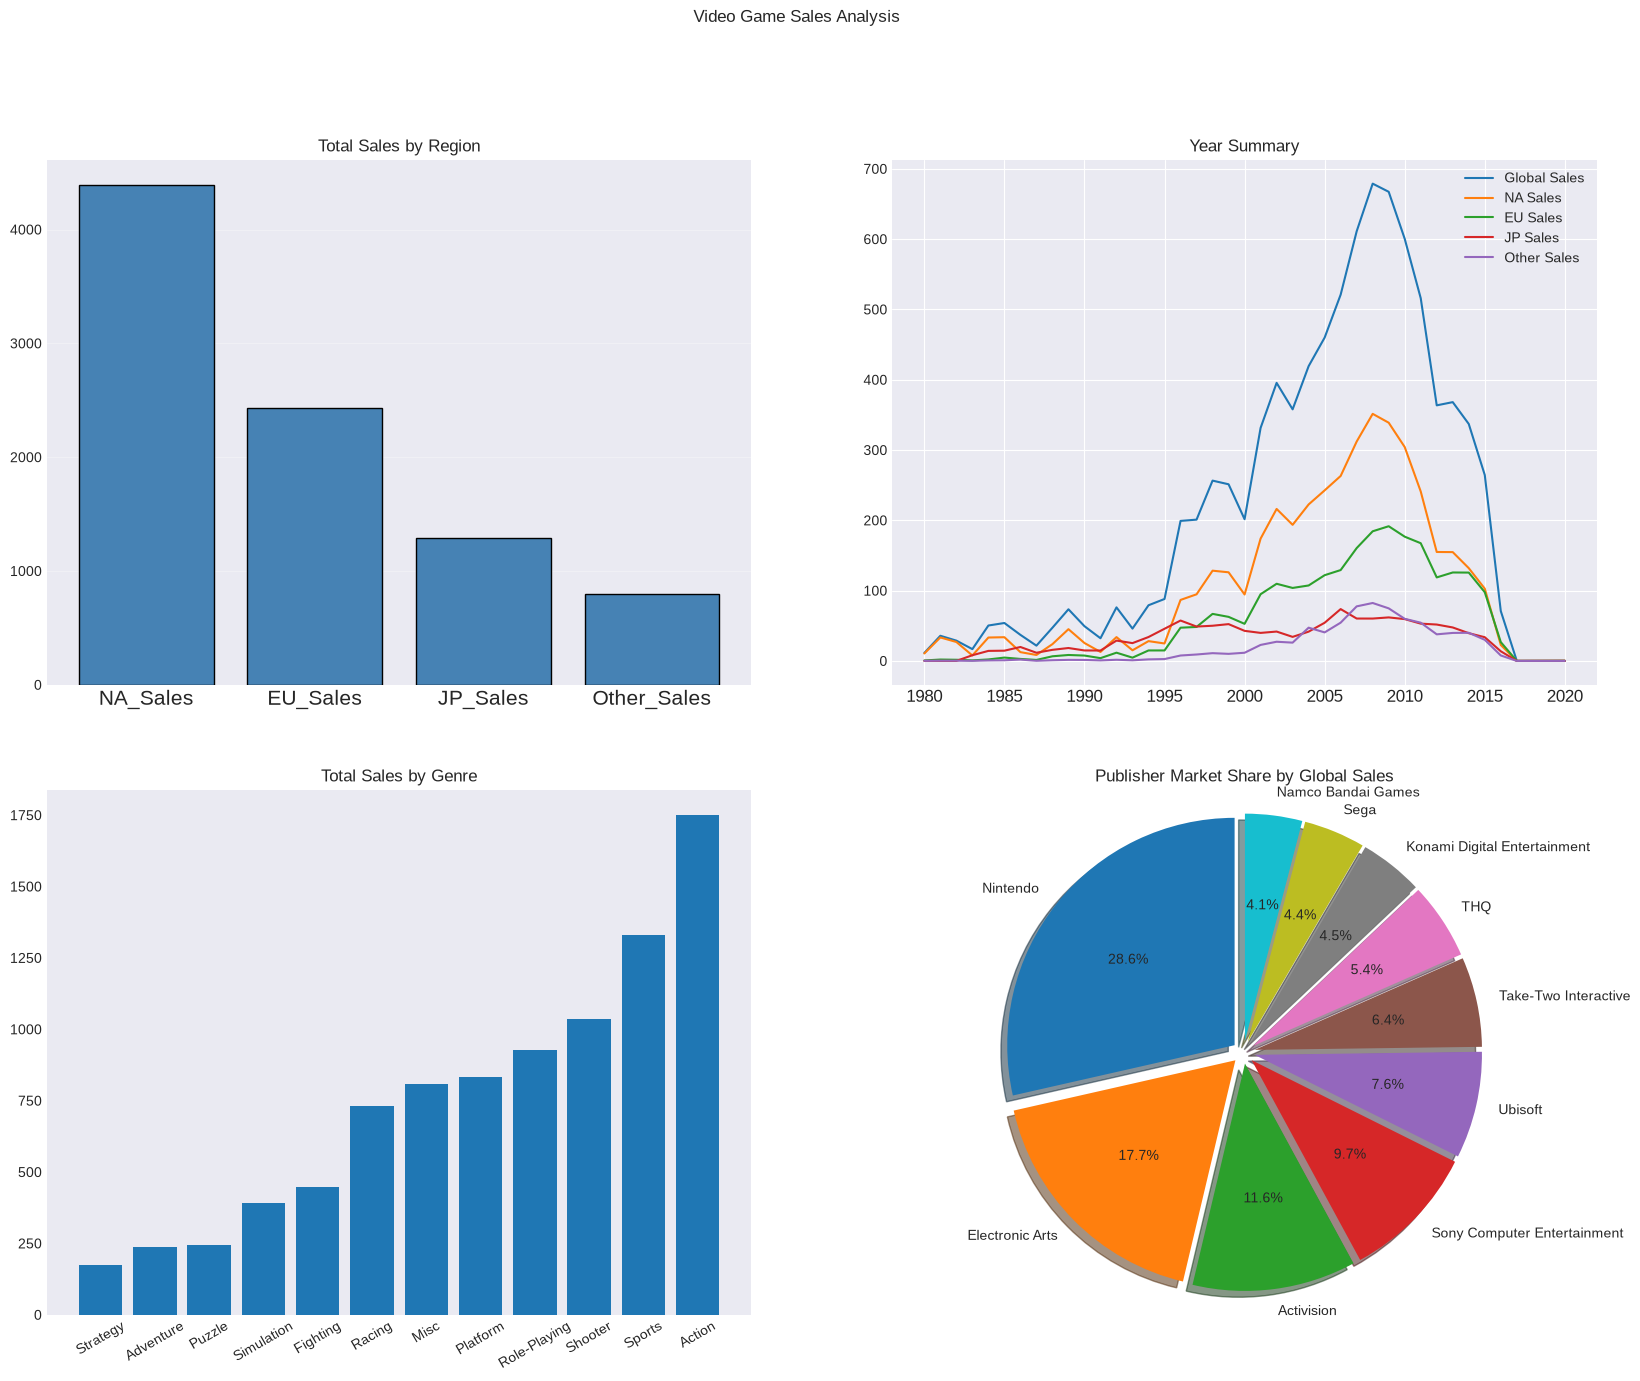

In [45]:
fig, axes = plt.subplots(2,2, figsize = (20, 15))
fig.suptitle("Video Game Sales Analysis")

# Top Left

all_sales = ["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]
for sale in (all_sales):
    axes[0,0].bar(sale,np.sum(vg_sales[sale]), edgecolor = "black", label = sale, color = "steelblue")

axes[0,0].grid(True, axis= "y", alpha = 0.3,)
axes[0,0].set_title('Total Sales by Region')
axes[0,0].tick_params(axis= "x", labelsize = 15)

#Top Right

year_summary = vg_sales.groupby("Year", as_index=False).agg(
    Global_Sales = ("Global_Sales", "sum"),
    NA_Sales = ("NA_Sales", "sum"),
    EU_Sales = ("EU_Sales", "sum"),
    JP_Sales= ("JP_Sales", "sum"),
    Other_Sales= ("Other_Sales", "sum")
)

x = year_summary["Year"]


axes[0,1].set_title("Year Summary")
axes[0,1].grid("True")
axes[0,1].minorticks_on()

axes[0,1].plot(x,year_summary["Global_Sales"], label = "Global Sales")
axes[0,1].plot(x,year_summary["NA_Sales"],label = "NA Sales")
axes[0,1].plot(x,year_summary["EU_Sales"],label = "EU Sales")
axes[0,1].plot(x,year_summary["JP_Sales"],label = "JP Sales")
axes[0,1].plot(x,year_summary["Other_Sales"],label = "Other Sales")
axes[0,1].legend()
axes[0,1].tick_params(axis = "x", labelsize = 12)
#Bottom Left

# Display the totals sales for each genre
genre_sales = {}
count = []

genre_summary = vg_sales.groupby("Genre").agg(
    Global_Sales = ("Global_Sales", "sum"),
    Count = ("Genre","size")
).reset_index()


axes[1,0].bar(genre_summary.sort_values("Global_Sales",ascending = True)["Genre"],genre_summary.sort_values("Global_Sales",ascending = True)["Global_Sales"])
axes[1,0].set_title("Total Sales by Genre")
# Reduce x-axis tick label size and rotate for readability
axes[1,0].tick_params(axis = "x", rotation = 30)
# Bottom right

market_summary = vg_sales.groupby("Publisher", as_index=False).agg(
    Global_Sales=("Global_Sales", "sum")
).sort_values("Global_Sales", ascending=False)

x = market_summary["Global_Sales"][0:10]
y = market_summary["Publisher"][0:10]

axes[1,1].pie(
    x,
    labels=y,
    autopct="%1.1f%%",
    startangle=90,
    shadow = True,
    explode = [0.05 for i in range(len(x))]
)
axes[1,1].axis("equal")

axes[1,1].set_title("Publisher Market Share by Global Sales")


plt.show()
axes[0,0].grid(True, axis= "y", alpha = 0.3,)
axes[0,0].set_title('Total Sales by Region')
axes[0,0].tick_params(axis= "x", labelsize = 15)

#Top Right

year_summary = vg_sales.groupby("Year", as_index=False).agg(
    Global_Sales = ("Global_Sales", "sum"),
    NA_Sales = ("NA_Sales", "sum"),
    EU_Sales = ("EU_Sales", "sum"),
    JP_Sales= ("JP_Sales", "sum"),
    Other_Sales= ("Other_Sales", "sum")
)

x = year_summary["Year"]


axes[0,1].set_title("Year Summary")
axes[0,1].grid("True")
axes[0,1].minorticks_on()

axes[0,1].plot(x,year_summary["Global_Sales"], label = "Global Sales")
axes[0,1].plot(x,year_summary["NA_Sales"],label = "NA Sales")
axes[0,1].plot(x,year_summary["EU_Sales"],label = "EU Sales")
axes[0,1].plot(x,year_summary["JP_Sales"],label = "JP Sales")
axes[0,1].plot(x,year_summary["Other_Sales"],label = "Other Sales")
axes[0,1].legend()
axes[0,1].tick_params(axis = "x", labelsize = 12)

#Bottom Left

genre_summary = vg_sales.groupby("Genre").agg(
    Global_Sales = ("Global_Sales", "sum"),
    Count = ("Genre","size")
).reset_index()


axes[1,0].bar(genre_summary.sort_values("Global_Sales",ascending = True)["Genre"],genre_summary.sort_values("Global_Sales",ascending = True)["Global_Sales"])
axes[1,0].set_title("Total Sales by Genre")
# Reduce x-axis tick label size and rotate for readability
axes[1,0].tick_params(axis = "x", rotation = 30)
# Bottom right

market_summary = vg_sales.groupby("Publisher", as_index=False).agg(
    Global_Sales=("Global_Sales", "sum")
).sort_values("Global_Sales", ascending=False)

x = market_summary["Global_Sales"][0:10]
y = market_summary["Publisher"][0:10]

axes[1,1].pie(
    x,
    labels=y,
    autopct="%1.1f%%",
    startangle=90,
    shadow = True,
    explode = [0.05 for i in range(len(x))]
)
axes[1,1].axis("equal")

axes[1,1].set_title("Publisher Market Share by Global Sales")


plt.show()

### Copied code for readability while looking at chart

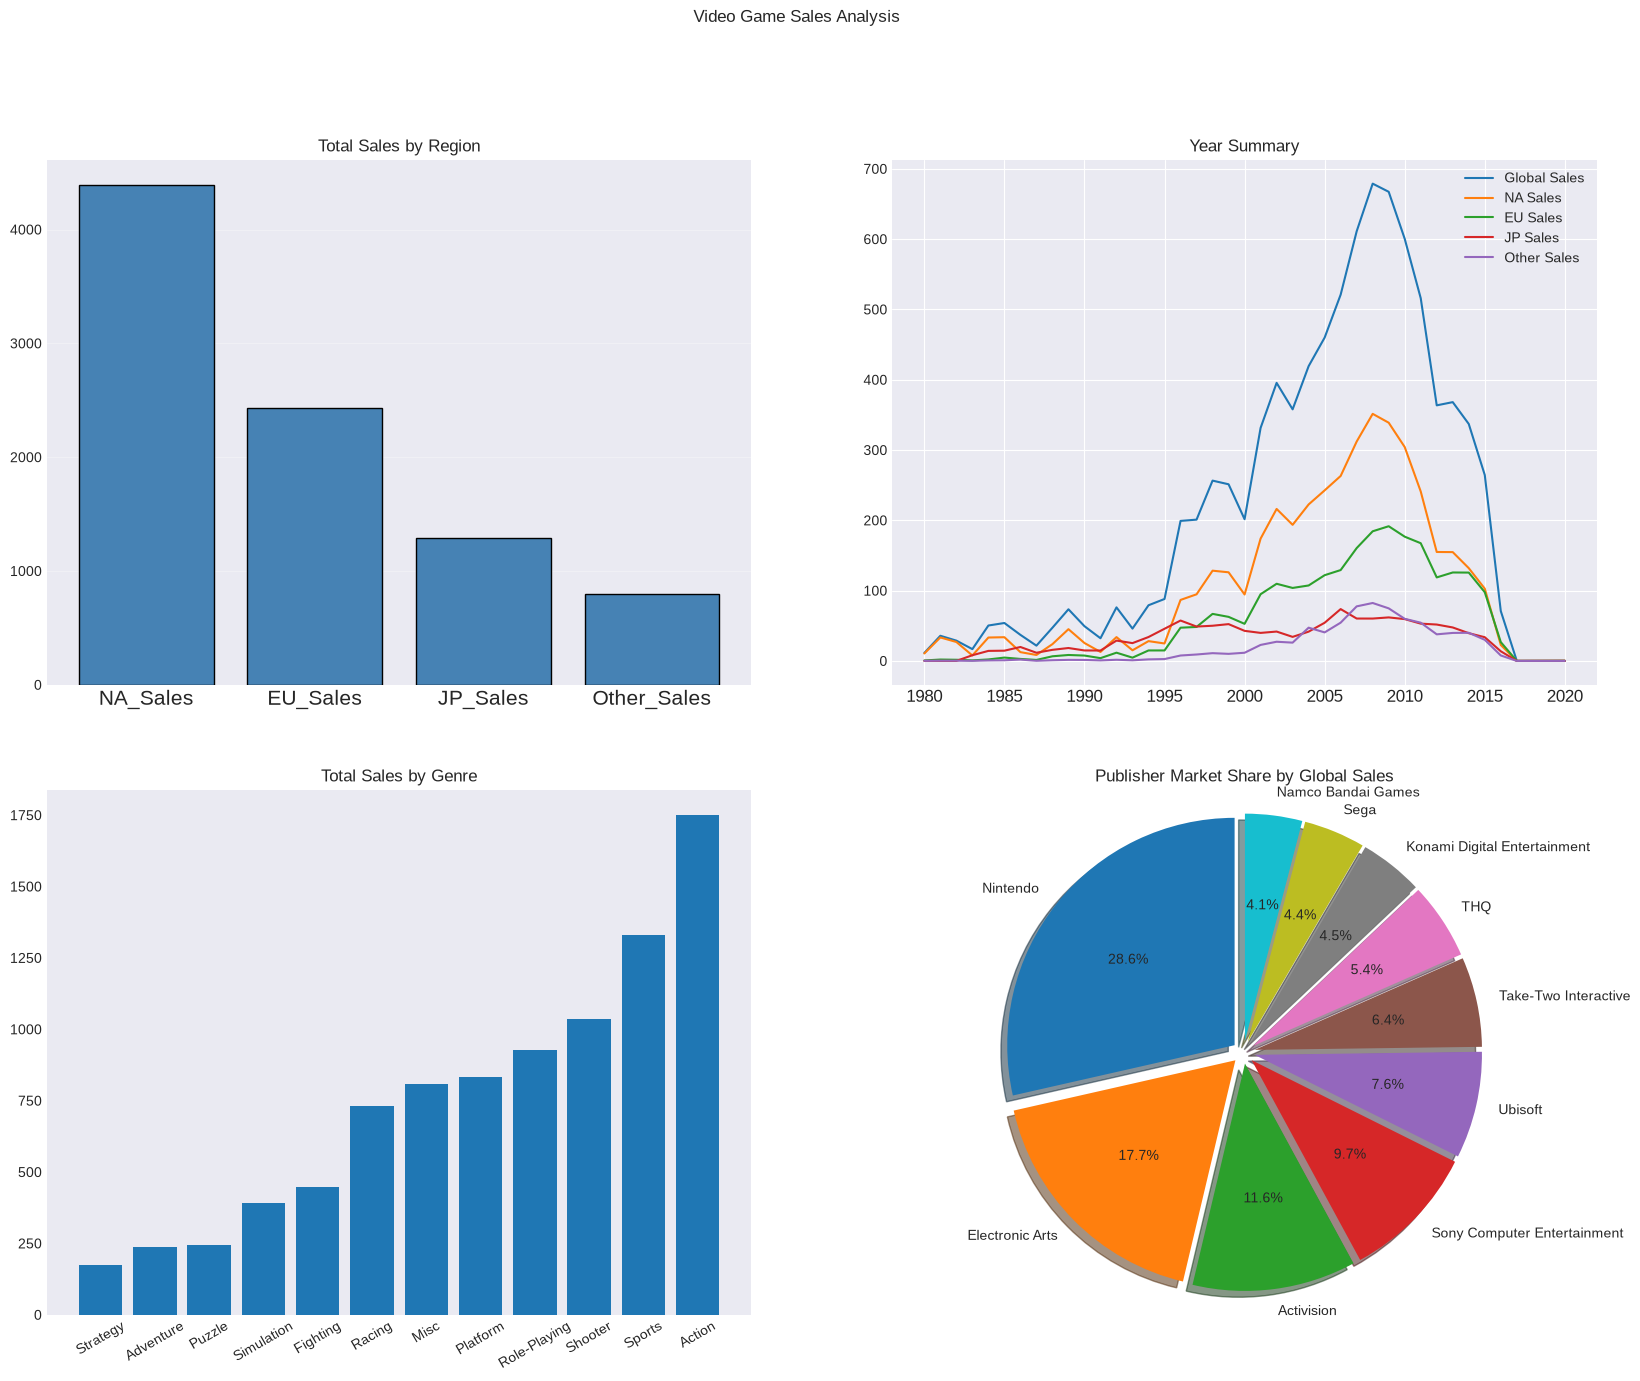

In [44]:
fig, axes = plt.subplots(2,2, figsize = (20, 15))
fig.suptitle("Video Game Sales Analysis")

# Top Left

all_sales = ["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]
for sale in (all_sales):
    axes[0,0].bar(sale,np.sum(vg_sales[sale]), edgecolor = "black", label = sale, color = "steelblue")

axes[0,0].grid(True, axis= "y", alpha = 0.3,)
axes[0,0].set_title('Total Sales by Region')
axes[0,0].tick_params(axis= "x", labelsize = 15)

#Top Right

year_summary = vg_sales.groupby("Year", as_index=False).agg(
    Global_Sales = ("Global_Sales", "sum"),
    NA_Sales = ("NA_Sales", "sum"),
    EU_Sales = ("EU_Sales", "sum"),
    JP_Sales= ("JP_Sales", "sum"),
    Other_Sales= ("Other_Sales", "sum")
)

x = year_summary["Year"]


axes[0,1].set_title("Year Summary")
axes[0,1].grid("True")
axes[0,1].minorticks_on()

axes[0,1].plot(x,year_summary["Global_Sales"], label = "Global Sales")
axes[0,1].plot(x,year_summary["NA_Sales"],label = "NA Sales")
axes[0,1].plot(x,year_summary["EU_Sales"],label = "EU Sales")
axes[0,1].plot(x,year_summary["JP_Sales"],label = "JP Sales")
axes[0,1].plot(x,year_summary["Other_Sales"],label = "Other Sales")
axes[0,1].legend()
axes[0,1].tick_params(axis = "x", labelsize = 12)
#Bottom Left

# Display the totals sales for each genre
genre_sales = {}
count = []

genre_summary = vg_sales.groupby("Genre").agg(
    Global_Sales = ("Global_Sales", "sum"),
    Count = ("Genre","size")
).reset_index()


axes[1,0].bar(genre_summary.sort_values("Global_Sales",ascending = True)["Genre"],genre_summary.sort_values("Global_Sales",ascending = True)["Global_Sales"])
axes[1,0].set_title("Total Sales by Genre")
# Reduce x-axis tick label size and rotate for readability
axes[1,0].tick_params(axis = "x", rotation = 30)
# Bottom right

market_summary = vg_sales.groupby("Publisher", as_index=False).agg(
    Global_Sales=("Global_Sales", "sum")
).sort_values("Global_Sales", ascending=False)

x = market_summary["Global_Sales"][0:10]
y = market_summary["Publisher"][0:10]

axes[1,1].pie(
    x,
    labels=y,
    autopct="%1.1f%%",
    startangle=90,
    shadow = True,
    explode = [0.05 for i in range(len(x))]
)
axes[1,1].axis("equal")

axes[1,1].set_title("Publisher Market Share by Global Sales")


plt.show()

In [ ]:
print("--- Quantile---") # Quantile, shows the percentage of data below
print(vg_sales["Global_Sales"].quantile(0.12))

print()

print("---Standard Deviation---") # Shows how spread out numbers are from average(mean)
print(vg_sales["Global_Sales"].std())

print()


print("---Mean---")# Average
print(vg_sales["Global_Sales"].mean())
print("---Median---") # Exact middle number
print(vg_sales["Global_Sales"].median())
np.where()

--- Quantile---
0.03

---Standard Deviation---
1.5550279355699126

---Mean---
0.5374406555006629
---Median---
0.17
---Mode---
0    0.02
Name: Global_Sales, dtype: float64
